In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
sns.set_palette("twilight")
%matplotlib inline

# Import Dataset


In [3]:
train_df = pd.read_csv(r"../input/titanic/train.csv")

In [4]:
#train copy
train = train_df.copy()

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train.shape

(891, 12)

# Test Data

In [7]:
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")
test = test_df.copy()
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [8]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


# EDA


In [10]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
cat_feature = ["Survived", "Pclass", "Sex", "SibSp", "Parch", "Embarked"]

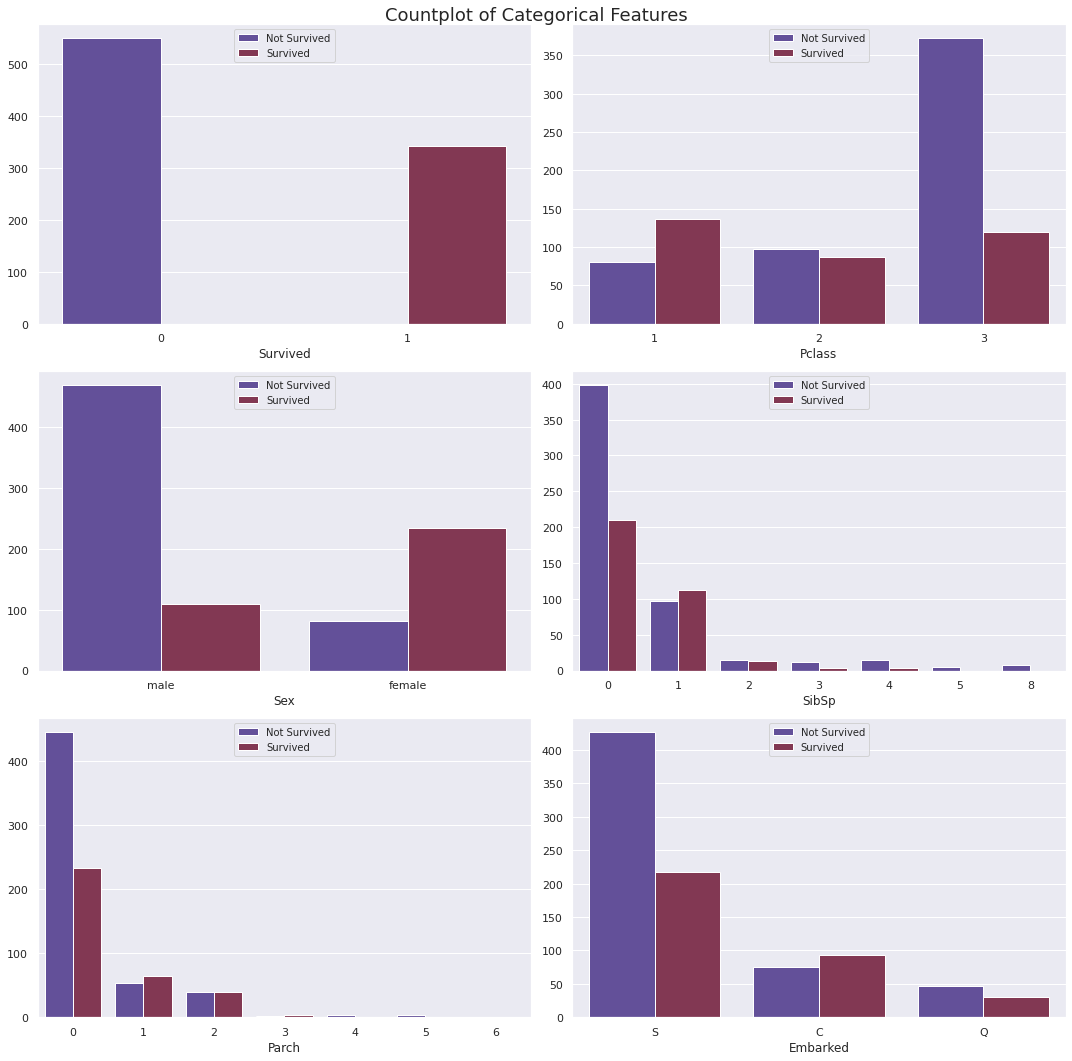

In [13]:
plt.figure(figsize = (15,15))
plt.suptitle("Countplot of Categorical Features", fontsize=18)
for i in cat_feature: 
    plt.subplot(3,2,cat_feature.index(i)+1)
    sns.countplot(data = train, x = i, hue = "Survived", palette="twilight")
    plt.ylabel("")
    plt.legend(['Not Survived', 'Survived'], loc='upper center', prop={'size': 10})
plt.tight_layout()
plt.show()

In [14]:
num_feature = ["Age", "Fare"]

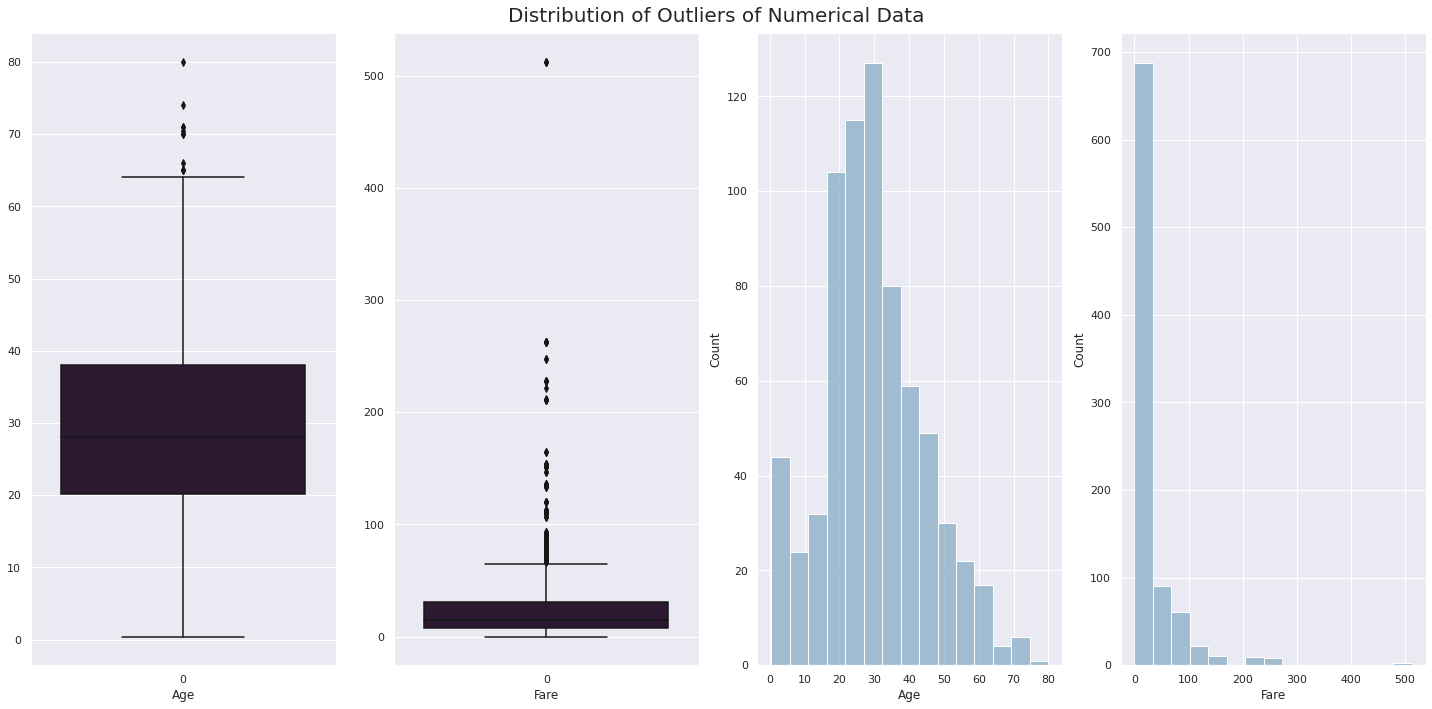

In [15]:
plt.figure(figsize=(20,10))
plt.suptitle("Distribution of Outliers of Numerical Data", fontsize=20)

# Box-plot
for i in num_feature:
    plt.subplot(1,4,num_feature.index(i)+1)
    sns.boxplot(data = train[i], palette="twilight")
    plt.xlabel(str(i))
    
# Histogram    
for i in num_feature:
    plt.subplot(1,4,num_feature.index(i)+3)
    sns.histplot(data = train[i], palette="twilight", bins=15)
    plt.xlabel(str(i))
    
plt.tight_layout()
plt.show()

# remove unimportant columns



In [16]:
train.drop(columns=["PassengerId", "Name", "Ticket","Cabin"], inplace=True)
PassengerId_test =test["PassengerId"]
test.drop(columns=["PassengerId", "Name", "Ticket","Cabin"], inplace=True)


In [17]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [19]:
data = [train, test]
for dataset in data:
    dataset['relatives'] = dataset['SibSp'] + dataset['Parch']
    dataset.loc[dataset['relatives'] > 0, 'travelled_alone'] = 'No'
    dataset.loc[dataset['relatives'] == 0, 'travelled_alone'] = 'Yes'

In [20]:
y_train = train["Survived"]
x_train = train.drop(columns=["Survived"])

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_vald, y_train, y_vald = train_test_split(x_train, y_train, 
                                                    test_size=0.2, random_state=0)

In [22]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,relatives,travelled_alone
140,3,female,NaN,0,2,15.2458,C,2,No
439,2,male,31.0,0,0,10.5000,S,0,Yes
817,2,male,31.0,1,1,37.0042,C,2,No
378,3,male,20.0,0,0,4.0125,C,0,Yes
491,3,male,21.0,0,0,7.2500,S,0,Yes


In [23]:
X_train.shape

(712, 9)

In [24]:
X_vald.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,relatives,travelled_alone
495,3,male,NaN,0,0,14.4583,C,0,Yes
648,3,male,NaN,0,0,7.5500,S,0,Yes
278,3,male,7.0,4,1,29.1250,Q,5,No
31,1,female,NaN,1,0,146.5208,C,1,No
255,3,female,29.0,0,2,15.2458,C,2,No


In [25]:
X_vald.shape

(179, 9)

In [26]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,relatives,travelled_alone
0,3,male,34.5,0,0,7.8292,Q,0,Yes
1,3,female,47.0,1,0,7.0000,S,1,No
2,2,male,62.0,0,0,9.6875,Q,0,Yes
3,3,male,27.0,0,0,8.6625,S,0,Yes
4,3,female,22.0,1,1,12.2875,S,2,No


# Feature Engineering 

In [27]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

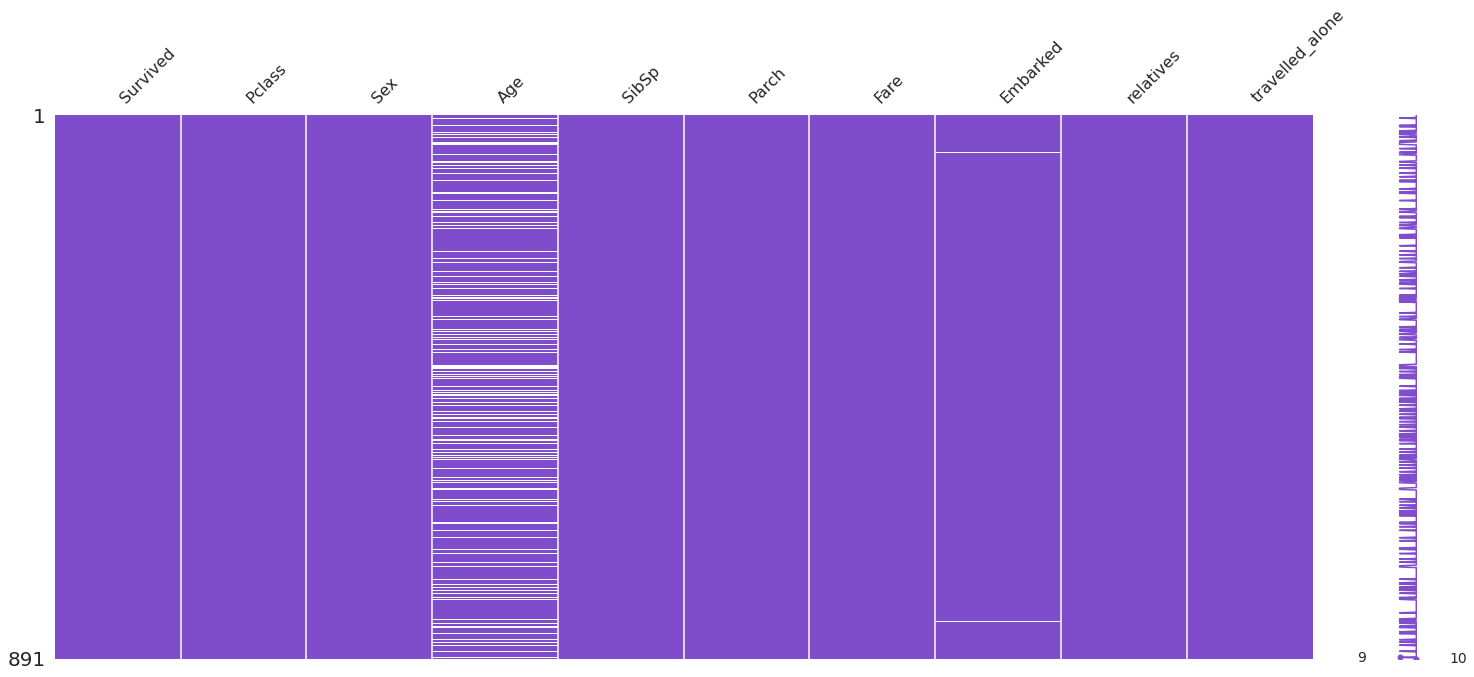

Total Missing Values in dataset : Survived             0
Pclass               0
Sex                  0
Age                177
SibSp                0
Parch                0
Fare                 0
Embarked             2
relatives            0
travelled_alone      0
dtype: int64
Data Type of x :  <class 'pandas.core.series.Series'>
There are 177 missing values in column: Age
There are 2 missing values in column: Embarked


In [28]:
import missingno as msno
msno.matrix(train , color=(0.50,0.30,0.80))
plt.show()
x = train.isnull().sum()
print("Total Missing Values in dataset :",x)
print("Data Type of x : ",type(x))
for a, b in x.items():
    if b > 0:
        print(f"There are {b} missing values in column: {a}")

# Filling null values

In [29]:
# X_train["Cabin"].fillna("undefined", inplace=True)
# X_vald["Cabin"].fillna("undefined", inplace=True)
# test["Cabin"].fillna("undefined", inplace=True)

In [30]:
X_train.isnull().sum()

Pclass               0
Sex                  0
Age                141
SibSp                0
Parch                0
Fare                 0
Embarked             2
relatives            0
travelled_alone      0
dtype: int64

In [31]:
X_vald.isnull().sum()

Pclass              0
Sex                 0
Age                36
SibSp               0
Parch               0
Fare                0
Embarked            0
relatives           0
travelled_alone     0
dtype: int64

In [32]:
test.isnull().sum()

Pclass              0
Sex                 0
Age                86
SibSp               0
Parch               0
Fare                1
Embarked            0
relatives           0
travelled_alone     0
dtype: int64

In [33]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 712 entries, 140 to 684
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Pclass           712 non-null    int64  
 1   Sex              712 non-null    object 
 2   Age              571 non-null    float64
 3   SibSp            712 non-null    int64  
 4   Parch            712 non-null    int64  
 5   Fare             712 non-null    float64
 6   Embarked         710 non-null    object 
 7   relatives        712 non-null    int64  
 8   travelled_alone  712 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 55.6+ KB


In [34]:
X_train.isnull().sum()

Pclass               0
Sex                  0
Age                141
SibSp                0
Parch                0
Fare                 0
Embarked             2
relatives            0
travelled_alone      0
dtype: int64

In [35]:
X_train['SibSp'].value_counts()

0    486
1    167
2     24
4     14
3     10
8      7
5      4
Name: SibSp, dtype: int64

In [36]:
numeric_features = ['Age', 'Fare']
# Define a pipeline for numeric features
numeric_features_pipeline = Pipeline(steps= [
    ('imputer', SimpleImputer(strategy = 'median')), # Impute with median value for missing
    ('scaler', StandardScaler())])

In [37]:
categorical_features = ['Embarked', 'Sex','travelled_alone']
# Define a pipeline for categorical features
categorical_features_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value = 'missing')), # Impute with the word 'missing' for missing values
    ('onehot', OneHotEncoder(sparse=False, handle_unknown="ignore"))])

In [38]:
ordinal_features = ['Pclass']
# Define a pipline for ordinal features 
ordinal_features_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

In [39]:
preprocessor = ColumnTransformer(transformers= [
    ('num', numeric_features_pipeline, numeric_features),        # transformer with name 'num' that will apply 'numeric_features_pipeline' to numeric_features
    ('cat', categorical_features_pipeline, categorical_features), # transformer with name 'cat' that will apply 'categorical_features_pipeline' to categorical_features
    ('ord', ordinal_features_pipeline, ordinal_features)
])

# Build pipeline of models

In [40]:
clf = Pipeline(steps=[('preprocessor', preprocessor),
                     ('classifier', LogisticRegression(solver = 'lbfgs'))])

In [41]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncod

In [42]:
X_vald['Pclass'].value_counts()

3    95
1    46
2    38
Name: Pclass, dtype: int64

# Prediction and Accuracy Score

In [43]:
y_pred = clf.predict(X_vald)
y_pred

array([0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

In [44]:
from sklearn.metrics import accuracy_score
c = accuracy_score(y_vald, y_pred)
c

0.7988826815642458

In [45]:
y_pred2 = clf.predict(test)

In [46]:
y_pred2

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [47]:
output = pd.DataFrame({'PassengerId': PassengerId_test, 'Survived': y_pred2})
output.to_csv('submission.csv', index=False)


In [48]:
output.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [49]:
output.shape

(418, 2)